In [117]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, Annotated
from langchain_ollama import ChatOllama
from langchain_core.messages import SystemMessage, HumanMessage
import operator #reducer

In [118]:
generator_llm = ChatOllama(model = 'llama3.2')
evaluator_llm = ChatOllama(model = 'llama3.2')
optimizer_llm = ChatOllama(model = 'llama3.2')

In [119]:
from pydantic import BaseModel, Field
class TweetEvaluation(BaseModel):
    evaluation: Literal['approve', 'need_improvement'] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="Feedback for the tweet.")

In [120]:
evaluator_llm_structured = evaluator_llm.with_structured_output(TweetEvaluation)

In [121]:
class TweetState(TypedDict):
    topic: str
    tweet: str
    evaluation: Literal['approved', 'needs_improvement']
    feedback: str
    iteration: int
    max_iterations: int

    tweet_history : Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]


In [122]:
def generate_tweet(state: TweetState):

    # prompt
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
""")
    ]

    # send generator_llm
    response = generator_llm.invoke(messages).content

    # return response
    return {'tweet': response, 'tweet_history': [response]}

In [123]:
def evaluator_tweet(state: TweetState) -> TweetState:
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]
    response = evaluator_llm_structured.invoke(messages)
    
    return {'evaluation' : response.evaluation, 'feedback' : response.feedback, 'feedback_history':[response.feedback]}

In [124]:
def optimizer_tweet(state: TweetState) -> TweetState:
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimizer_llm.invoke(messages)
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [125]:
def route_evaluator(state: TweetState) -> str:
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iterations']:
        return 'approved'
    else:
        return 'need_improvement'

In [126]:
graph = StateGraph(TweetState)
graph.add_node('generate', generate_tweet)
graph.add_node('evaluator', evaluator_tweet)
graph.add_node('optimizer', optimizer_tweet)

graph.add_edge(START, 'generate')
graph.add_edge('generate', 'evaluator')

graph.add_conditional_edges('evaluator', route_evaluator, {'approved':END, 'need_improvement':'optimizer'})
graph.add_edge('optimizer', 'evaluator')

workflow = graph.compile()


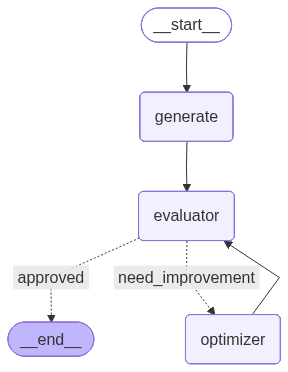

In [127]:
workflow

In [128]:
initial_state = {
    "topic": "indian Railways",
    "iteration": 1,
    "max_iterations": 5,
}

result = workflow.invoke(initial_state)

In [129]:
result

{'topic': 'indian Railways',
 'tweet': AIMessage(content='Here\'s the revised tweet:\n\n"Train food existential crisis: stale biscuits = will to live? Indian Railways, where every meal is a struggle to survive #IndianRailways #TrainFood"\n\nChanges made:\n\n* Kept it concise and under 280 characters\n* Emphasized the humor and absurdity of train food\n* Used a more direct and attention-grabbing opening line ("train food existential crisis")\n* Ended with a relatable phrase ("will to live")', additional_kwargs={}, response_metadata={'model': 'llama3.2', 'created_at': '2026-06-24T05:29:09.083496Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3552314542, 'load_duration': 52605375, 'prompt_eval_count': 467, 'prompt_eval_duration': 1168065084, 'eval_count': 97, 'eval_duration': 2227722461, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'}, id='lc_run--019ef81a-7afa-7533-a34a-616d85126f72-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens

In [132]:
for tweet in result['tweet_history']:
    print(tweet)

"Just spent 5 hours on an Indian Railway train and I'm pretty sure the chef's signature dish is now 'stale biscuit' Anyone need a souvenir from my journey? #IndianRailways #TrainFood"
content='Here\'s a revised version of the tweet:\n\n"Just spent 5 hours on an Indian Railway train & I\'m pretty sure \'stale biscuit\' is now its national dish Anyone need a souvenir from my existential crisis? #IndianRailways #TrainFood"\n\nI made some changes to enhance the humor and brevity, including:\n\n* Using more vivid language ("existential crisis") to emphasize the absurdity of the situation\n* Adding a bit of wordplay with "souvenir" to maintain the joke\'s lighthearted tone\n* Emphasizing the relatable experience by using "Anyone need" to make it seem like anyone could be in a similar predicament\n\nThis revised tweet aims to poke fun at the absurdity of train food while also highlighting the universal frustration that comes with it, making it more likely to resonate with a wider audience.' a